# 02 | Scaled Dot-Product Attention
## Sprint 2 — Day 1

**Previous notebook:** `01` — token embeddings and positional encoding.
Input shape entering this notebook: `(batch_size, seq_len, d_model)`.

---

This is the core of the Transformer. Everything else in the architecture
exists to support or stack this mechanism.

Self-attention answers one question: *for each token in the sequence,
how much should it attend to every other token when building its
representation?*

We do this by projecting our input into three separate matrices —
**Queries (Q)**, **Keys (K)**, and **Values (V)** — then computing a
weighted sum of the values, where the weights come from the similarity
between queries and keys.

---

**By the end of this notebook you will have:**
- Understood what Q, K, and V are and where they come from
- Understood why we scale by √d_k (connected back to your RAG work
  on vector magnitudes and dot product instability)
- Implemented single-head scaled dot-product attention from scratch
- Visualised an attention weight matrix as a heatmap

---

*Next notebook: `03_multi_head_attention.ipynb`*
```

***NOTEBOOK SETUP CELL***

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)

# --- Config ---
d_model    = 64
d_k        = 64
max_seq_len = 50
vocab_size  = 256
batch_size  = 2
seq_len     = 10

# --- Positional Encoding (from Sprint 1) ---
def positional_encoding(max_seq_len, d_model):
    PE = torch.zeros(max_seq_len, d_model)
    position = torch.arange(0, max_seq_len).unsqueeze(1).float()
    div_term = torch.pow(10000.0, torch.arange(0, d_model, 2).float() / d_model)
    PE[:, 0::2] = torch.sin(position / div_term)
    PE[:, 1::2] = torch.cos(position / div_term)
    return PE

# --- Input Embedding (from Sprint 1) ---
class InputEmbedding(nn.Module):
    def __init__(self, vocab_size, d_model, max_seq_len):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pe = positional_encoding(max_seq_len, d_model)

    def forward(self, x):
        token_embeddings = self.embedding(x)
        seq_len = x.shape[1]
        return token_embeddings + self.pe[:seq_len, :]

embed_layer = InputEmbedding(vocab_size, d_model, max_seq_len)

print("Setup complete.")
print(f"d_model={d_model} | d_k={d_k} | vocab_size={vocab_size} | seq_len={seq_len} | batch_size={batch_size}")

Setup complete.
d_model=64 | d_k=64 | vocab_size=256 | seq_len=10 | batch_size=2


**ATTENTION FUNCTION**

In [2]:
import torch
import torch.nn.functional as F

def scaled_dot_product_attention(Q, K, V):
    d_k = Q.shape[-1]
    scores = torch.matmul(Q, K.transpose(-2, -1))
    scores = scores / (d_k ** 0.5)
    weights = F.softmax(scores, dim=-1)
    output = torch.matmul(weights, V)
    return output, weights

**SINGLE-HEAD ATTENTION MODULE**

In [3]:
import torch.nn as nn

class SingleHeadAttention(nn.Module):
    def __init__(self, d_model, d_k):
        super().__init__()
        self.W_Q = nn.Linear(d_model, d_k, bias=False)
        self.W_K = nn.Linear(d_model, d_k, bias=False)
        self.W_V = nn.Linear(d_model, d_k, bias=False)

    def forward(self, x):
        Q = self.W_Q(x)
        K = self.W_K(x)
        V = self.W_V(x)
        output, weights = scaled_dot_product_attention(Q, K, V)
        return output, weights

**SANITY CHECK**

In [4]:
d_model = 64
d_k = 64
seq_len = 10
batch_size = 2

embed_layer = InputEmbedding(vocab_size, d_model, max_seq_len)
dummy_tokens = torch.randint(0, vocab_size, (batch_size, seq_len))
x = embed_layer(dummy_tokens)

attn = SingleHeadAttention(d_model, d_k)
output, weights = attn(x)

print(f"Input shape:          {x.shape}")
print(f"Attention out shape:  {output.shape}")
print(f"Attention weights:    {weights.shape}")

Input shape:          torch.Size([2, 10, 64])
Attention out shape:  torch.Size([2, 10, 64])
Attention weights:    torch.Size([2, 10, 10])


**VISUALIZING THE ATTENTION WEIGHT MATRIX**

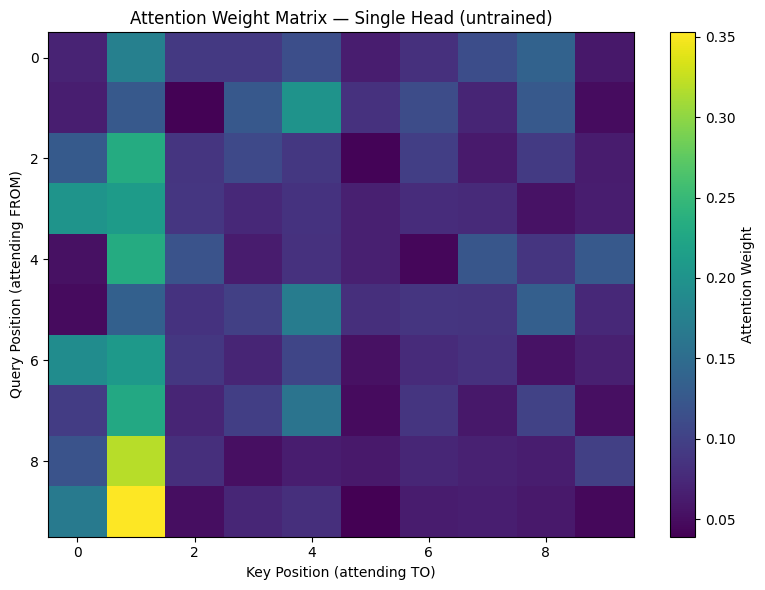

In [5]:
import matplotlib.pyplot as plt

single_weights = weights[0].detach().numpy()

plt.figure(figsize=(8, 6))
plt.imshow(single_weights, cmap='viridis', aspect='auto')
plt.colorbar(label='Attention Weight')
plt.xlabel('Key Position (attending TO)')
plt.ylabel('Query Position (attending FROM)')
plt.title('Attention Weight Matrix — Single Head (untrained)')
plt.tight_layout()
plt.show()

# Sprint 2 Summary — Scaled Dot-Product Attention

---

## What This Sprint Built

A mechanism that allows every token in a sequence to look at every other token,
decide how relevant each one is, and blend their information into its own representation.
This is the core operation of the entire Transformer. Everything else exists to support or stack it.

---

## The Problem Attention Solves

After Sprint 1, every token has a vector — but that vector is **context-free**.
The word "bank" carries the same embedding whether the sentence is about money or a river.
Attention fixes this: it lets each token reach out to surrounding tokens, pull in their context,
and produce an output vector that reflects *meaning in this specific sentence*, not just average meaning.

---

## Q, K, V — Three Roles, One Source

The input matrix $X \in \mathbb{R}^{B \times T \times d_{model}}$ is projected three times through learned weight matrices:

$$Q = X W_Q \qquad K = X W_K \qquad V = X W_V$$

All three projections come from the same $X$. The weight matrices $W_Q$, $W_K$, $W_V$ are learned during training.

| Matrix | Role | Analogy |
|---|---|---|
| $Q$ (Query) | What this token is *looking for* | Your search query in a library |
| $K$ (Key) | What this token *advertises as containing* | A book's catalogue description |
| $V$ (Value) | The actual content this token *contributes* | The book's full text |

Matching Q against K decides **who to attend to**. Taking a weighted sum of V decides **what information to retrieve**.

---

## The Attention Score Matrix

$$\text{Scores} = QK^T \in \mathbb{R}^{B \times T \times T}$$

Entry $(i, j)$ is the dot product between the Query of token $i$ and the Key of token $j$.
High dot product means token $i$ finds token $j$ highly relevant.
This gives us every pairwise relevance score simultaneously — $T^2$ comparisons in one matrix multiply.

---

## The Scaling Problem

In high dimensions, dot products grow large. With $d_k$ components of unit variance:

$$\text{Var}(q \cdot k) = d_k \qquad \Rightarrow \qquad \text{std}(q \cdot k) = \sqrt{d_k}$$

Large inputs to softmax cause it to spike — one score dominates, all others collapse to near zero.
This destroys the weighted blend and kills gradients during backpropagation.

The fix — divide by $\sqrt{d_k}$ before softmax:

$$\text{Scores}_{\text{scaled}} = \frac{QK^T}{\sqrt{d_k}}$$

This restores unit variance to the scores and keeps softmax in a regime where it produces
meaningful distributions and healthy gradients.

---

## The Full Formula

$$\text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{QK^T}{\sqrt{d_k}}\right) V$$

Step by step:

| Step | Operation | Output Shape | What it produces |
|---|---|---|---|
| 1 | $QK^T$ | $(B, T, T)$ | Raw pairwise similarity scores |
| 2 | $/ \sqrt{d_k}$ | $(B, T, T)$ | Scaled scores — stable for softmax |
| 3 | $\text{softmax}(\cdot)$ | $(B, T, T)$ | Attention weights — each row sums to 1 |
| 4 | $A \cdot V$ | $(B, T, d_v)$ | Weighted blend of Values — context-enriched output |

---

## Reading the Attention Weight Heatmap

The $(T \times T)$ attention weight matrix visualised as a heatmap:

- **Each row** = one token's attention distribution across all positions
- **Each column** = how much all tokens collectively attended to that position
- **Bright cells** = strong attention — that token pair has high relevance
- **Dark cells** = near-zero attention — that pair is mostly ignored
- **Untrained model** = patterns driven by random initialisation, not learned semantics
- **Trained model** = sharp, structured patterns where each token attends to linguistically meaningful positions

---

## Connecting to Your RAG System

| RAG | Attention |
|---|---|
| Query embedding (question) | $Q$ — what each token is searching for |
| Document embeddings (chunks) | $K$ — what each token advertises |
| Retrieved chunks | $V$ — what gets blended into the output |
| Cosine similarity score | $QK^T / \sqrt{d_k}$ — relevance score |
| Top-k retrieval | Softmax weights — soft, differentiable version of retrieval |

RAG retrieves hard — you either include a chunk or you don't.
Attention retrieves soft — every token contributes, weighted by relevance.
The attention mechanism is a fully differentiable, learnable version of what you built in RAG.

---

## Key Takeaways

- Q, K, V are three **learned projections** of the same input — different roles, same source
- $QK^T$ gives every pairwise token similarity in one matrix multiply
- Dividing by $\sqrt{d_k}$ prevents softmax from spiking and gradients from vanishing
- Softmax converts raw scores into a **probability distribution** — each row sums to 1
- The output is a **weighted sum of Values** — each token's representation is now enriched by context
- Output shape is identical to input shape: $(B, T, d_{model})$ — attention is shape-preserving

---

*Next: Sprint 3 — Multi-Head Attention. One attention head looks at the sequence through one lens.
We now run multiple heads in parallel, each learning a different type of relationship.*